In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')
import cv2


C:\Users\ashut\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
C:\Users\ashut\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import cv2
import torch
import torchvision

In [3]:
# ===================== DATA PATHS =====================
TRAIN_DIR = "C:/Users/ashut/Desktop/XXX/casting_512x512"
TEST_DIR = "C:/Users/ashut/Desktop/XXX/casting_512x512"

# Count images
def_train = os.listdir(os.path.join(TRAIN_DIR, "def_front"))
ok_train = os.listdir(os.path.join(TRAIN_DIR, "ok_front"))
def_test = os.listdir(os.path.join(TEST_DIR, "def_front"))
ok_test = os.listdir(os.path.join(TEST_DIR, "ok_front"))

total_train = len(def_train) + len(ok_train)
total_test = len(def_test) + len(ok_test)
total_all = total_train + total_test

print("=" * 50)
print("📊 DATASET SUMMARY")
print("=" * 50)
print(f"Train → Defective: {len(def_train)}, OK: {len(ok_train)}, Total: {total_train}")
print(f"Test  → Defective: {len(def_test)},  OK: {len(ok_test)},  Total: {total_test}")
print(f"\nTotal images: {total_all}")

# ---------- Defective Percentage ----------
total_defective = len(def_train) + len(def_test)
total_ok = len(ok_train) + len(ok_test)
defective_pct = (total_defective / total_all) * 100
ok_pct = (total_ok / total_all) * 100

print(f"\n🔴 Defective parts: {total_defective} ({defective_pct:.2f}%)")
print(f"🟢 OK parts:        {total_ok} ({ok_pct:.2f}%)")
print("=" * 50)


📊 DATASET SUMMARY
Train → Defective: 781, OK: 519, Total: 1300
Test  → Defective: 781,  OK: 519,  Total: 1300

Total images: 2600

🔴 Defective parts: 1562 (60.08%)
🟢 OK parts:        1038 (39.92%)


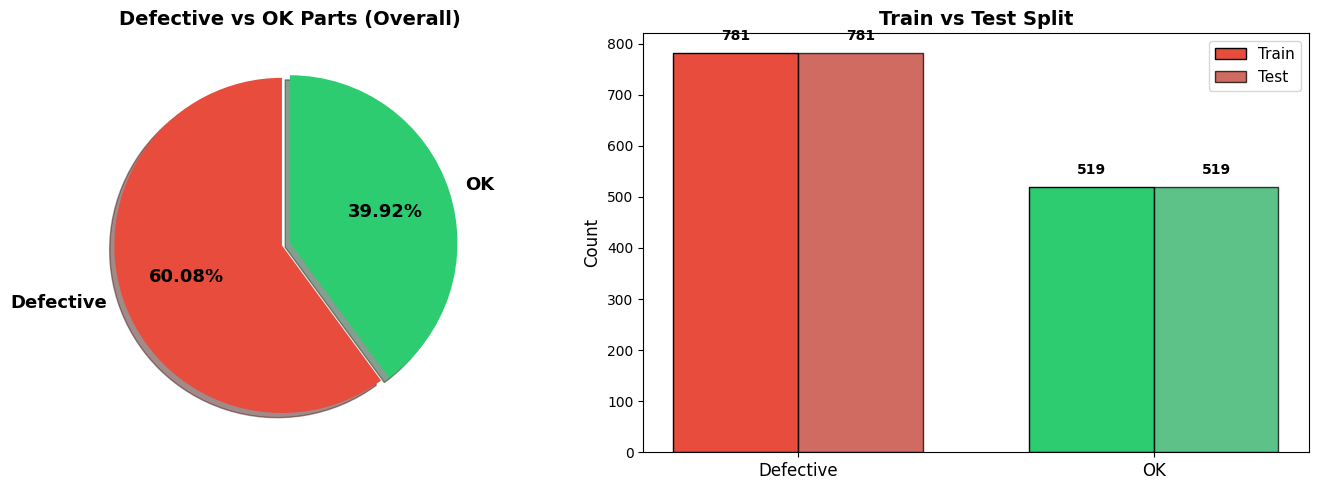

In [4]:
# ===================== DEFECTIVE vs OK PIE + BAR CHART =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie Chart
labels = ['Defective', 'OK']
sizes = [total_defective, total_ok]
colors = ['#e74c3c', '#2ecc71']
explode = (0.05, 0)
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.2f%%',
            shadow=True, startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Defective vs OK Parts (Overall)', fontsize=14, fontweight='bold')

# Bar Chart - Train vs Test split
x = np.arange(2)
width = 0.35
bars1 = axes[1].bar(x - width/2, [len(def_train), len(ok_train)], width, label='Train', color=['#e74c3c', '#2ecc71'], edgecolor='black')
bars2 = axes[1].bar(x + width/2, [len(def_test), len(ok_test)], width, label='Test', color=['#c0392b', '#27ae60'], edgecolor='black', alpha=0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Defective', 'OK'], fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Train vs Test Split', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


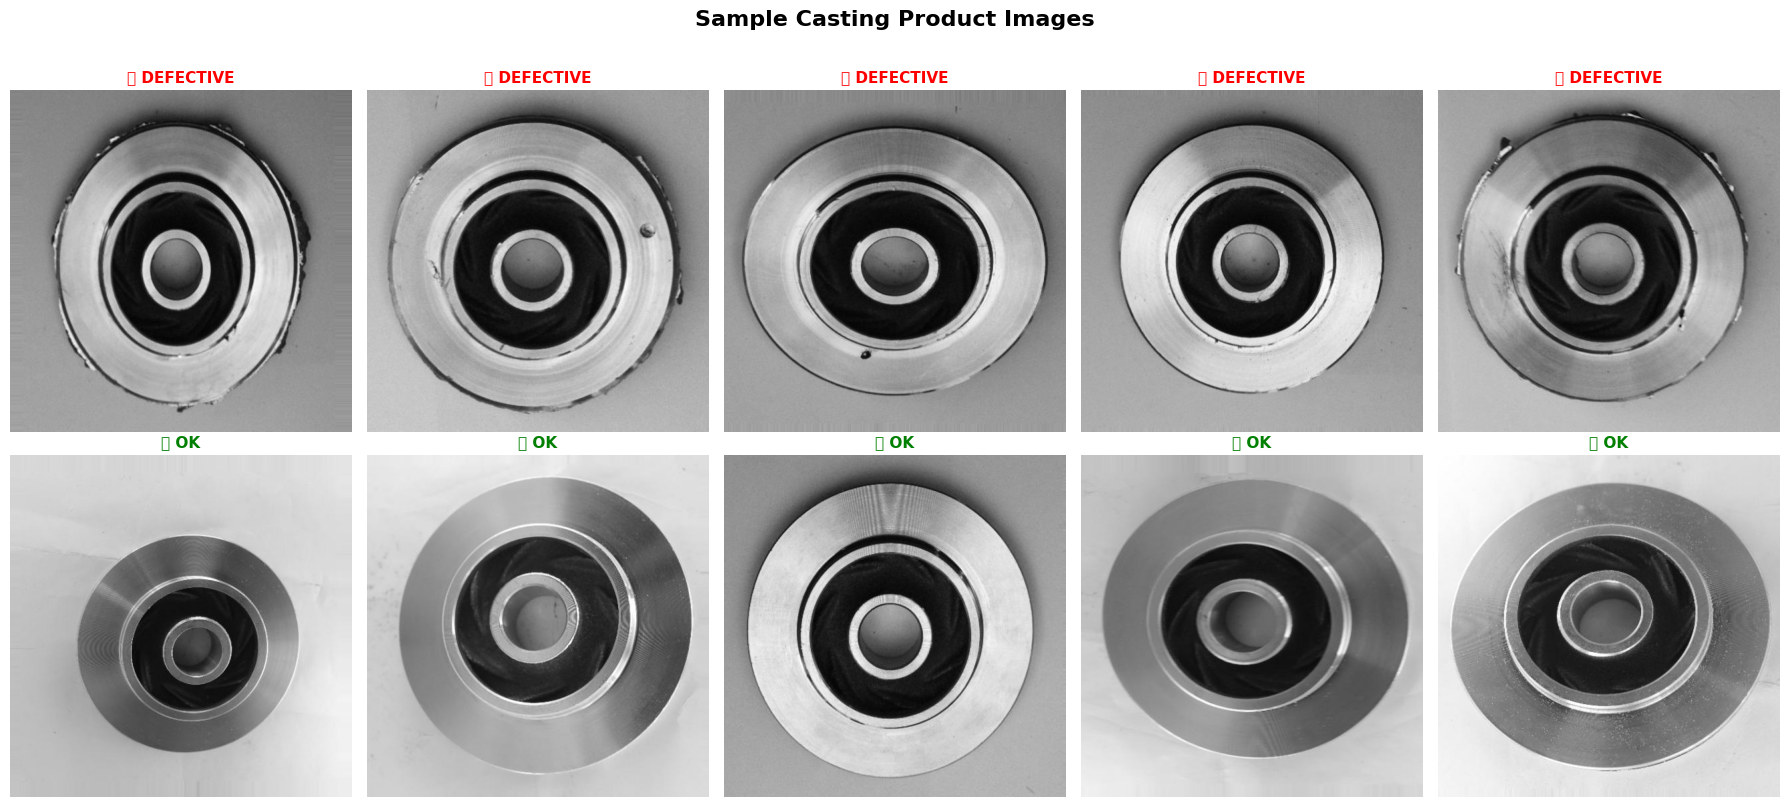

In [5]:
# ===================== SAMPLE IMAGES =====================
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i in range(5):
    img = cv2.imread(os.path.join(TRAIN_DIR, "def_front", def_train[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img)
    axes[0][i].set_title("🔴 DEFECTIVE", fontsize=11, fontweight='bold', color='red')
    axes[0][i].axis('off')

for i in range(5):
    img = cv2.imread(os.path.join(TRAIN_DIR, "ok_front", ok_train[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1][i].imshow(img)
    axes[1][i].set_title("🟢 OK", fontsize=11, fontweight='bold', color='green')
    axes[1][i].axis('off')

plt.suptitle("Sample Casting Product Images", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# ===================== CUSTOM DATASET CLASS =====================
class CastingDataset(Dataset):
    """
    Custom Dataset for Casting Product Image Classification
    Folder structure:
        data_dir/
            def_front/   -> label 0 (defective)
            ok_front/    -> label 1 (ok)
    """
    def __init__(self, data_dir, processor, augment=False):
        self.data_dir = data_dir
        self.processor = processor
        self.augment = augment
        
        self.image_paths = []
        self.labels = []
        self.class_names = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.class_names)}
        
        for class_name in self.class_names:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.isdir(class_dir):
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        self.image_paths.append(os.path.join(class_dir, img_name))
                        self.labels.append(self.class_to_idx[class_name])
        
        print(f"Found {len(self.image_paths)} images in {len(self.class_names)} classes")
        print(f"Classes: {self.class_names} -> {self.class_to_idx}")
        
        if augment:
            self.augment_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(15),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            ])
        else:
            self.augment_transform = None
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.augment_transform:
            image = self.augment_transform(image)
        
        inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze(0)
        label = self.labels[idx]
        
        return {"pixel_values": pixel_values, "labels": label}


In [7]:
# ===================== DEVICE, MODEL & PROCESSOR =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_name = "facebook/deit-small-patch16-224"

model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=1,                # Binary classification (BCEWithLogitsLoss)
    ignore_mismatched_sizes=True
).to(device)

processor = ViTImageProcessor.from_pretrained(model_name)

# ===================== DATALOADERS =====================
batch_size = 16

train_dataset = CastingDataset(TRAIN_DIR, processor=processor, augment=True)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size, num_workers=0)

val_dataset = CastingDataset(TEST_DIR, processor=processor, augment=False)
val_loader = DataLoader(val_dataset, shuffle=False, batch_size=batch_size, num_workers=0)

print(f"\nTrain batches: {len(train_loader)}, Val batches: {len(val_loader)}")


Using device: cpu


Some weights of ViTForImageClassification were not initialized from the model checkpoint at facebook/deit-small-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 384]) in the checkpoint and torch.Size([1, 384]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Found 1300 images in 2 classes
Classes: ['def_front', 'ok_front'] -> {'def_front': 0, 'ok_front': 1}
Found 1300 images in 2 classes
Classes: ['def_front', 'ok_front'] -> {'def_front': 0, 'ok_front': 1}

Train batches: 82, Val batches: 82


In [8]:
# ===================== HYPERPARAMETERS =====================
epochs = 10          # Fixed 10 epochs, NO early stopping
lr = 2e-5
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()

# ===================== TRACKING LISTS =====================
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_precisions, val_precisions = [], []
train_recalls, val_recalls = [], []
train_f1s, val_f1s = [], []

best_val_loss = float("inf")
checkpoint_dir = "best_vit_checkpoint"

# ===================== TRAINING LOOP - 10 EPOCHS, NO EARLY STOPPING =====================
for epoch in range(epochs):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"{'='*60}")

    # --------------------- TRAIN ---------------------
    model.train()
    running_loss = 0.0
    y_true_train, y_pred_train = [], []

    for batch in tqdm(train_loader, desc="Training"):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device).float()

        optimizer.zero_grad()

        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits.squeeze()
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).long()
        y_true_train.extend(labels.cpu().numpy())
        y_pred_train.extend(preds.cpu().numpy())

    train_loss = running_loss / len(train_loader)
    train_acc = accuracy_score(y_true_train, y_pred_train)
    train_precision = precision_score(y_true_train, y_pred_train, zero_division=0)
    train_recall = recall_score(y_true_train, y_pred_train, zero_division=0)
    train_f1 = f1_score(y_true_train, y_pred_train, zero_division=0)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)

    # --------------------- VALIDATION ---------------------
    model.eval()
    running_loss = 0.0
    y_true_val, y_pred_val = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            pixel_values = batch["pixel_values"].to(device)
            labels = batch["labels"].to(device).float()

            outputs = model(pixel_values=pixel_values)
            logits = outputs.logits.squeeze()
            loss = criterion(logits, labels)
            running_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).long()
            y_true_val.extend(labels.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = accuracy_score(y_true_val, y_pred_val)
    val_precision = precision_score(y_true_val, y_pred_val, zero_division=0)
    val_recall = recall_score(y_true_val, y_pred_val, zero_division=0)
    val_f1 = f1_score(y_true_val, y_pred_val, zero_division=0)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    # --------------------- SAVE BEST MODEL (but NO early stopping) ---------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"✅ New best val loss: {val_loss:.4f}. Saving checkpoint...")
        model.save_pretrained(checkpoint_dir)
        processor.save_pretrained(checkpoint_dir)

    # --------------------- LOG ---------------------
    print(f"Train | Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  Prec: {train_precision:.4f}  Rec: {train_recall:.4f}  F1: {train_f1:.4f}")
    print(f"Val   | Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  Prec: {val_precision:.4f}  Rec: {val_recall:.4f}  F1: {val_f1:.4f}")

print("\n" + "="*60)
print("🎉 Training Complete! All 10 epochs finished (no early stopping).")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: {checkpoint_dir}")
print("="*60)



Epoch [1/10]


Validation: 100%|██████████| 82/82 [01:31<00:00,  1.12s/it]


✅ New best val loss: 0.1172. Saving checkpoint...
Train | Loss: 0.2961  Acc: 0.8708  Prec: 0.8574  Rec: 0.8112  F1: 0.8337
Val   | Loss: 0.1172  Acc: 0.9631  Prec: 0.9153  Rec: 1.0000  F1: 0.9558

Epoch [2/10]


Validation: 100%|██████████| 82/82 [01:44<00:00,  1.27s/it]


✅ New best val loss: 0.0385. Saving checkpoint...
Train | Loss: 0.0771  Acc: 0.9731  Prec: 0.9583  Rec: 0.9750  F1: 0.9666
Val   | Loss: 0.0385  Acc: 0.9923  Prec: 0.9811  Rec: 1.0000  F1: 0.9905

Epoch [3/10]


...

✅ New best val loss: 0.0038. Saving checkpoint...
Train | Loss: 0.0342  Acc: 0.9892  Prec: 0.9828  Rec: 0.9904  F1: 0.9866
Val   | Loss: 0.0038  Acc: 1.0000  Prec: 1.0000  Rec: 1.0000  F1: 1.0000

Epoch [9/10]


Validation: 100%|██████████| 82/82 [00:47<00:00,  1.74it/s]


Train | Loss: 0.0189  Acc: 0.9938  Prec: 0.9923  Rec: 0.9923  F1: 0.9923
Val   | Loss: 0.0105  Acc: 0.9969  Prec: 0.9924  Rec: 1.0000  F1: 0.9962

Epoch [10/10]


Validation: 100%|██████████| 82/82 [00:47<00:00,  1.73it/s]

Train | Loss: 0.0211  Acc: 0.9931  Prec: 0.9885  Rec: 0.9942  F1: 0.9914
Val   | Loss: 0.0038  Acc: 0.9992  Prec: 0.9981  Rec: 1.0000  F1: 0.9990

🎉 Training Complete! All 10 epochs finished (no early stopping).
Best validation loss: 0.0038
Best model saved to: best_vit_checkpoint


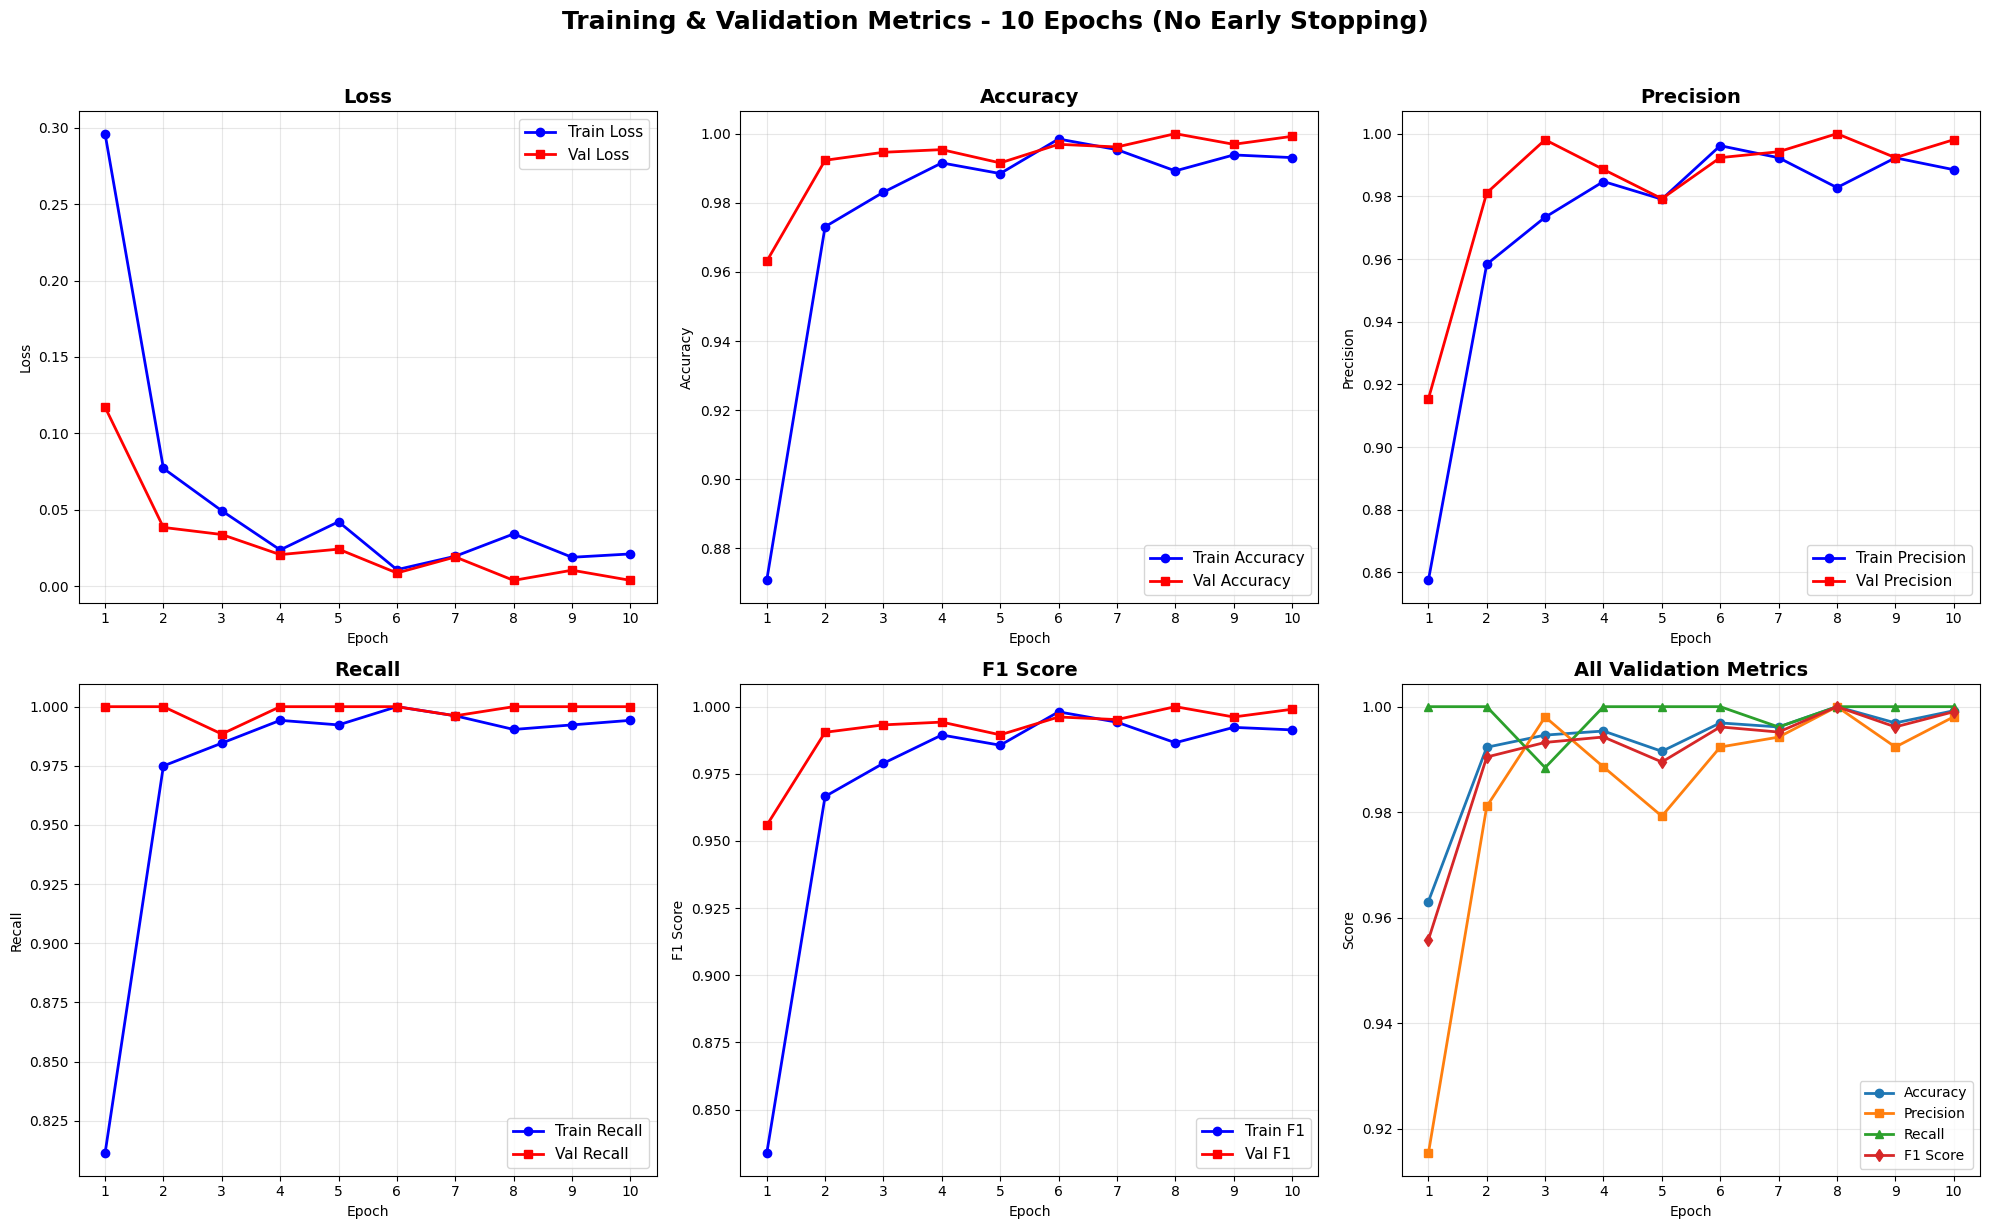

In [9]:
# ===================== PLOT ALL TRAINING GRAPHS =====================
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Training & Validation Metrics - 10 Epochs (No Early Stopping)', 
             fontsize=18, fontweight='bold', y=1.02)

# 1. Loss
axes[0, 0].plot(epochs_range, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[0, 0].plot(epochs_range, val_losses, 'r-s', label='Val Loss', linewidth=2, markersize=6)
axes[0, 0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy
axes[0, 1].plot(epochs_range, train_accs, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
axes[0, 1].plot(epochs_range, val_accs, 'r-s', label='Val Accuracy', linewidth=2, markersize=6)
axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision
axes[0, 2].plot(epochs_range, train_precisions, 'b-o', label='Train Precision', linewidth=2, markersize=6)
axes[0, 2].plot(epochs_range, val_precisions, 'r-s', label='Val Precision', linewidth=2, markersize=6)
axes[0, 2].set_title('Precision', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(True, alpha=0.3)

# 4. Recall
axes[1, 0].plot(epochs_range, train_recalls, 'b-o', label='Train Recall', linewidth=2, markersize=6)
axes[1, 0].plot(epochs_range, val_recalls, 'r-s', label='Val Recall', linewidth=2, markersize=6)
axes[1, 0].set_title('Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 5. F1 Score
axes[1, 1].plot(epochs_range, train_f1s, 'b-o', label='Train F1', linewidth=2, markersize=6)
axes[1, 1].plot(epochs_range, val_f1s, 'r-s', label='Val F1', linewidth=2, markersize=6)
axes[1, 1].set_title('F1 Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# 6. All Val Metrics Together
axes[1, 2].plot(epochs_range, val_accs, '-o', label='Accuracy', linewidth=2)
axes[1, 2].plot(epochs_range, val_precisions, '-s', label='Precision', linewidth=2)
axes[1, 2].plot(epochs_range, val_recalls, '-^', label='Recall', linewidth=2)
axes[1, 2].plot(epochs_range, val_f1s, '-d', label='F1 Score', linewidth=2)
axes[1, 2].set_title('All Validation Metrics', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Score')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xticks(list(epochs_range))

plt.tight_layout()
plt.show()


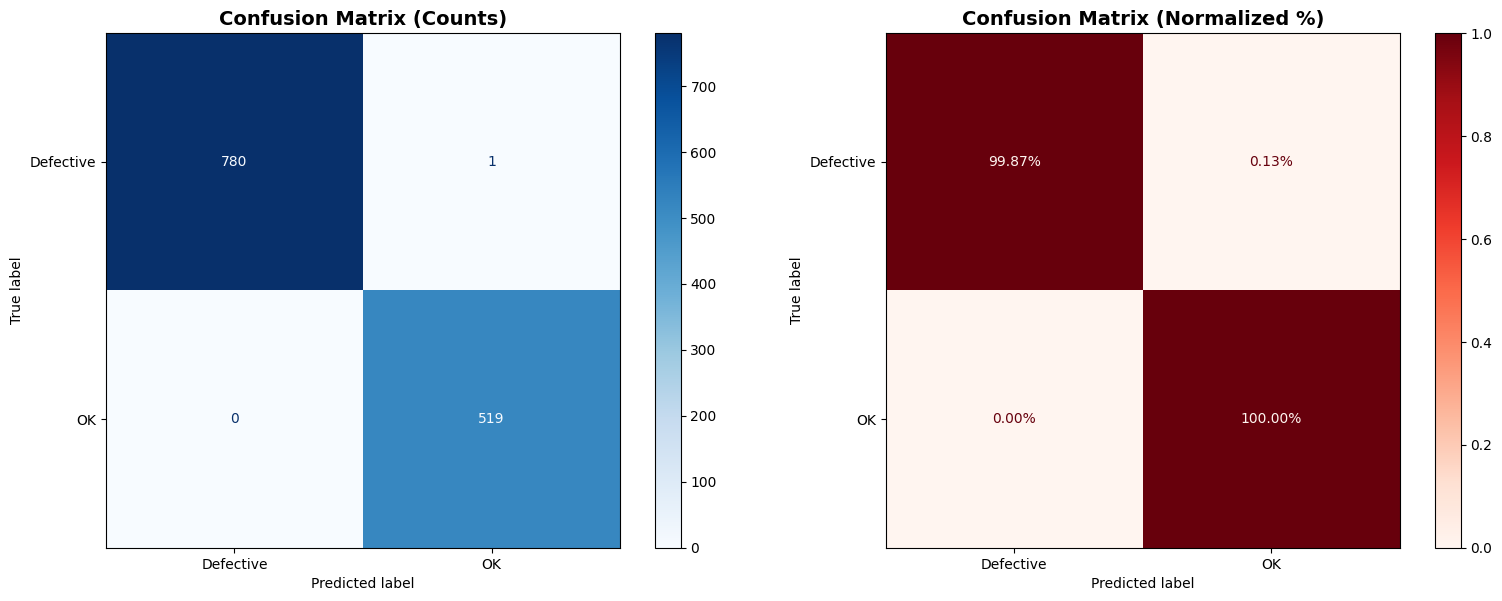


📋 CLASSIFICATION REPORT (Validation Set - Last Epoch)
              precision    recall  f1-score   support

   Defective       1.00      1.00      1.00       781
          OK       1.00      1.00      1.00       519

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



In [10]:
# ===================== CONFUSION MATRIX =====================
# Use last epoch's validation predictions
cm = confusion_matrix(y_true_val, y_pred_val)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix (Counts)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Defective', 'OK'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# 2. Confusion Matrix (Normalized / Percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Defective', 'OK'])
disp2.plot(ax=axes[1], cmap='Reds', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ===================== CLASSIFICATION REPORT =====================
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT (Validation Set - Last Epoch)")
print("="*60)
report = classification_report(y_true_val, y_pred_val, target_names=['Defective', 'OK'])
print(report)


In [11]:
# ===================== DEFECTIVE % ANALYSIS FROM MODEL =====================
y_true_arr = np.array(y_true_val)
y_pred_arr = np.array(y_pred_val)

# In dataset: class 0 = def_front (Defective), class 1 = ok_front (OK)
actual_defective = np.sum(y_true_arr == 0)
actual_ok = np.sum(y_true_arr == 1)
predicted_defective = np.sum(y_pred_arr == 0)
predicted_ok = np.sum(y_pred_arr == 1)

total_val = len(y_true_arr)

print("="*60)
print("📊 DEFECTIVE PARTS ANALYSIS (Validation Set)")
print("="*60)
print(f"\n📌 ACTUAL (Ground Truth):")
print(f"   Defective: {actual_defective}/{total_val} ({actual_defective/total_val*100:.2f}%)")
print(f"   OK:        {actual_ok}/{total_val} ({actual_ok/total_val*100:.2f}%)")
print(f"\n🤖 MODEL PREDICTIONS:")
print(f"   Predicted Defective: {predicted_defective}/{total_val} ({predicted_defective/total_val*100:.2f}%)")
print(f"   Predicted OK:        {predicted_ok}/{total_val} ({predicted_ok/total_val*100:.2f}%)")

# Correctly/incorrectly identified defective
TP_def = np.sum((y_true_arr == 0) & (y_pred_arr == 0))  # Correctly caught defective
FN_def = np.sum((y_true_arr == 0) & (y_pred_arr == 1))  # Missed defective (dangerous!)
FP_def = np.sum((y_true_arr == 1) & (y_pred_arr == 0))  # Falsely marked as defective

print(f"\n🔍 DEFECTIVE DETECTION BREAKDOWN:")
print(f"   ✅ Correctly caught defective:     {TP_def}")
print(f"   ❌ Missed defective (FALSE OK):     {FN_def}  ⚠️  CRITICAL - These defective parts passed QC!")
print(f"   ⚠️  False alarm (OK marked defect): {FP_def}")

if actual_defective > 0:
    defect_catch_rate = TP_def / actual_defective * 100
    defect_miss_rate = FN_def / actual_defective * 100
    print(f"\n   📈 Defect Catch Rate: {defect_catch_rate:.2f}%")
    print(f"   📉 Defect Miss Rate:  {defect_miss_rate:.2f}%")
print("="*60)


📊 DEFECTIVE PARTS ANALYSIS (Validation Set)

📌 ACTUAL (Ground Truth):
   Defective: 781/1300 (60.08%)
   OK:        519/1300 (39.92%)

🤖 MODEL PREDICTIONS:
   Predicted Defective: 780/1300 (60.00%)
   Predicted OK:        520/1300 (40.00%)

🔍 DEFECTIVE DETECTION BREAKDOWN:
   ✅ Correctly caught defective:     780
   ❌ Missed defective (FALSE OK):     1  ⚠️  CRITICAL - These defective parts passed QC!
   ⚠️  False alarm (OK marked defect): 0

   📈 Defect Catch Rate: 99.87%
   📉 Defect Miss Rate:  0.13%


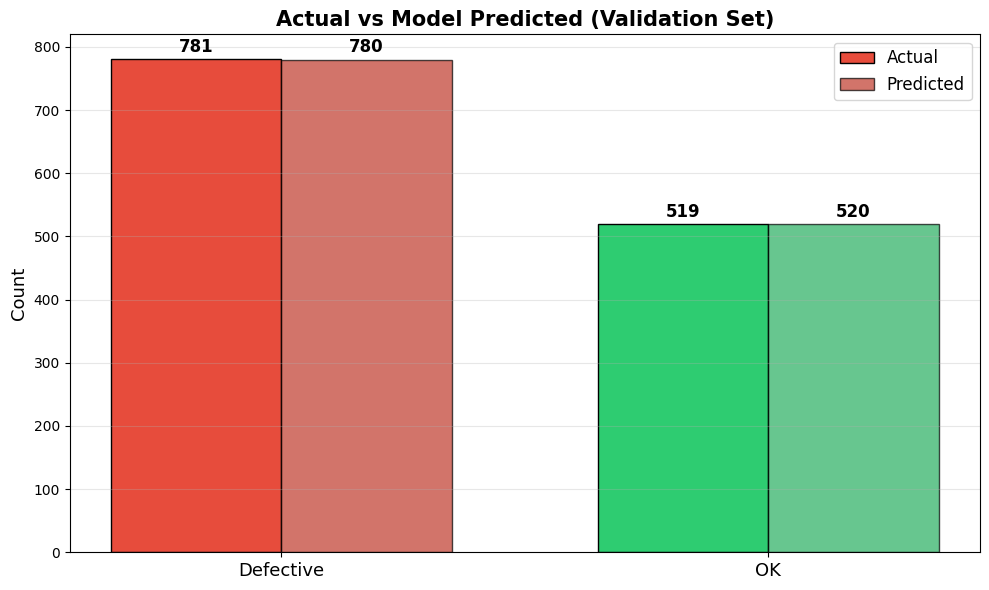

In [12]:
# ===================== ACTUAL vs PREDICTED BAR CHART =====================
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Defective', 'OK']
actual_counts = [actual_defective, actual_ok]
pred_counts = [predicted_defective, predicted_ok]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, actual_counts, width, label='Actual', color=['#e74c3c', '#2ecc71'], edgecolor='black')
bars2 = ax.bar(x + width/2, pred_counts, width, label='Predicted', color=['#c0392b', '#27ae60'], edgecolor='black', alpha=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=12)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title('Actual vs Model Predicted (Validation Set)', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# ===================== FINAL SUMMARY TABLE =====================
print("\n" + "="*70)
print("📋 EPOCH-WISE TRAINING SUMMARY")
print("="*70)

summary_data = {
    'Epoch': list(range(1, epochs+1)),
    'Train Loss': [f'{x:.4f}' for x in train_losses],
    'Val Loss': [f'{x:.4f}' for x in val_losses],
    'Train Acc': [f'{x:.4f}' for x in train_accs],
    'Val Acc': [f'{x:.4f}' for x in val_accs],
    'Val Prec': [f'{x:.4f}' for x in val_precisions],
    'Val Rec': [f'{x:.4f}' for x in val_recalls],
    'Val F1': [f'{x:.4f}' for x in val_f1s],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n🏆 Best Epoch (by Val Loss): Epoch {val_losses.index(min(val_losses))+1}")
print(f"   Val Loss: {min(val_losses):.4f}")
best_idx = val_losses.index(min(val_losses))
print(f"   Val Acc:  {val_accs[best_idx]:.4f}")
print(f"   Val F1:   {val_f1s[best_idx]:.4f}")
print("="*70)



📋 EPOCH-WISE TRAINING SUMMARY
 Epoch Train Loss Val Loss Train Acc Val Acc Val Prec Val Rec Val F1
     1     0.2961   0.1172    0.8708  0.9631   0.9153  1.0000 0.9558
     2     0.0771   0.0385    0.9731  0.9923   0.9811  1.0000 0.9905
     3     0.0494   0.0338    0.9831  0.9946   0.9981  0.9884 0.9932
     4     0.0238   0.0207    0.9915  0.9954   0.9886  1.0000 0.9943
     5     0.0422   0.0243    0.9885  0.9915   0.9792  1.0000 0.9895
     6     0.0108   0.0087    0.9985  0.9969   0.9924  1.0000 0.9962
     7     0.0196   0.0191    0.9954  0.9962   0.9942  0.9961 0.9952
     8     0.0342   0.0038    0.9892  1.0000   1.0000  1.0000 1.0000
     9     0.0189   0.0105    0.9938  0.9969   0.9924  1.0000 0.9962
    10     0.0211   0.0038    0.9931  0.9992   0.9981  1.0000 0.9990

🏆 Best Epoch (by Val Loss): Epoch 8
   Val Loss: 0.0038
   Val Acc:  1.0000
   Val F1:   1.0000
